# Metamodel for instrument RB1S (RBOB Gasoline)

In [4]:
%pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [21]:

import hmmlearn
from sklearn.preprocessing import StandardScaler

# Import required libraries
import pandas as pd
import numpy as np
import datetime
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Machine learning libraries
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance

# HMM models
import hmmlearn

# Set random seeds for reproducibility
import random
import os

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

In [22]:
# Load the OHLCV commodities data from a CSV file, keep only commodities
ohlcv = pd.read_csv('ohlcv_data.csv', index_col=0, parse_dates=True)
df = ohlcv[ohlcv['instrument'].isin(['cl1s', 'ho1s', 'rb1s', 'ng1s'])]
df = df.sort_values(["instrument", "date"])
g = df.groupby("instrument")
df.head()

,instrument,open,high,low,close,volume,open_interest
date,,,,,,,
1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0
1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0
1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0
1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0
1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0


## Feature Engineering
Build a rich feature set using the following:
- Technical Indicators
- Latent Variable Models (GMM, HMMs)

In [23]:
# Log returns
df["log_ret"] = g["close"].transform(lambda x: np.log(x / x.shift(1)))

# Returns over different horizons 
for n in [5, 10, 20, 60]:
    df[f"ret_{n}d"] = g["close"].transform(lambda x: np.log(x / x.shift(n)))

# Rolling realised volatility
for n in [5, 20, 60]:
    df[f"vol_{n}d"] = g["log_ret"].transform(
        lambda x: x.rolling(n).std() * np.sqrt(252)
    )

# Parkinson volatility (better for commodities)
df["parkinson"] = (
    np.log(df["high"] / df["low"]) ** 2) / (4 * np.log(2))

# Moving average ratios
for n in [10, 20, 50]:
    ma = g["close"].transform(lambda x: x.rolling(n).mean())
    df[f"ma_ratio_{n}"] = df["close"] / ma

# RSI (mean-reversion signal)
def rsi(x, n=14):
    delta = x.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df["rsi_14"] = g["close"].transform(rsi)

# Volume Z-score
vol_mean = g["volume"].transform(
    lambda x: x.rolling(20).mean()
)

vol_std = g["volume"].transform(
    lambda x: x.rolling(20).std()
)

df["volume_z"] = (df["volume"] - vol_mean) / vol_std


# Open interest changes (if rising price + rising open interest = strong trend)
df["oi_change"] = g["open_interest"].transform(
    lambda x: x.pct_change()
)

### Intraday Range features:
# True range
prev_close = g["close"].shift(1)

tr = pd.concat([
    df["high"] - df["low"],
    abs(df["high"] - prev_close),
    abs(df["low"] - prev_close)
], axis=1).max(axis=1)

# ATR
df["true_range"] = tr

df["atr_14"] = g["true_range"].transform(
    lambda x: x.rolling(14).mean()
)

### Cross sectional features:

# Cross sectional momentum ranks
df["mom_rank"] = (
    df.groupby("date")["ret_20d"]
      .rank(pct=True)
)

# RElative volatility
df["vol_rank"] = (
    df.groupby("date")["vol_20d"]
      .rank(pct=True)
)

df.head()

,instrument,open,high,low,close,volume,open_interest,log_ret,ret_5d,ret_10d,...,ma_ratio_10,ma_ratio_20,ma_ratio_50,rsi_14,volume_z,oi_change,true_range,atr_14,mom_rank,vol_rank
date,,,,,,,,,,,,,,,,,,,,,
1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.13,NaN,NaN,NaN
1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0,0.033931,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.073596,0.91,NaN,NaN,NaN
1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0,-0.011468,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.007049,1.09,NaN,NaN,NaN
1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0,-0.014197,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.061267,0.67,NaN,NaN,NaN
1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0,-0.065348,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.045653,1.53,NaN,NaN,NaN


### Hidden Markov Model

Use HMM rather than GMM as adds time dependence

In [24]:
from hmmlearn.hmm import GaussianHMM

def fit_hmm(df_instrument, feature_cols, n_states=3):
    """
    Fit HMM on one instrument's features.
    Returns the instrument df with new columns: hmm_state, hmm_prob_0, hmm_prob_1, hmm_prob_2 
    (3 states to avoid overfitting)
    """
    # Drop rows with NaNs in features
    X = df_instrument[feature_cols].dropna()
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit HMM
    model = GaussianHMM(n_components=n_states, covariance_type="diag", 
                        n_iter=100, random_state=42)
    model.fit(X_scaled)
    
    # Predict states and state probabilities
    states = model.predict(X_scaled)
    probs  = model.predict_proba(X_scaled)   # shape (T, n_states)
    
    # Write back into the slice (aligned by index)
    df_instrument = df_instrument.copy()
    df_instrument.loc[X.index, "hmm_state"] = states
    for k in range(n_states):
        df_instrument.loc[X.index, f"hmm_prob_{k}"] = probs[:, k]
    
    return df_instrument


# Features to feed into the HMM — keep it small and interpretable
HMM_FEATURES = ["log_ret", "vol_20d", "rsi_14", "volume_z", "parkinson"]

# Apply per instrument
results = []
for instr, grp in df.groupby("instrument"):
    grp_with_hmm = fit_hmm(grp, HMM_FEATURES, n_states=3)
    results.append(grp_with_hmm)

df = pd.concat(results).sort_values(["instrument", "date"])

print(df[["instrument", "hmm_state", "hmm_prob_0", "hmm_prob_1", "hmm_prob_2"]].dropna().head(10))

           instrument  hmm_state  hmm_prob_0    hmm_prob_1  hmm_prob_2
date                                                                  
1990-01-30       cl1s        0.0    1.000000  1.205780e-47         0.0
1990-01-31       cl1s        0.0    0.999964  3.637486e-05         0.0
1990-02-01       cl1s        0.0    0.999955  4.470228e-05         0.0
1990-02-02       cl1s        0.0    0.999962  3.799792e-05         0.0
1990-02-05       cl1s        0.0    0.999940  6.044495e-05         0.0
1990-02-06       cl1s        0.0    0.999985  1.535246e-05         0.0
1990-02-07       cl1s        0.0    0.999978  2.189091e-05         0.0
1990-02-08       cl1s        0.0    0.999974  2.552641e-05         0.0
1990-02-09       cl1s        0.0    0.999966  3.389364e-05         0.0
1990-02-12       cl1s        0.0    0.999974  2.617245e-05         0.0


In [25]:
# What does each state look like on average?
df.groupby(["instrument", "hmm_state"])[HMM_FEATURES].mean().round(3)

log_ret  vol_20d  rsi_14  volume_z  parkinson
instrument hmm_state                                               
cl1s       0.0          0.001    0.282  52.314    -0.018      0.000
           1.0         -0.003    0.649  46.014     0.229      0.002
           2.0         -0.569    2.405  30.981     3.718      0.559
ho1s       0.0         -0.000    0.607  49.319     0.143      0.001
           1.0          0.000    0.339  50.145    -0.018      0.000
           2.0          0.000    0.203  52.826    -0.008      0.000
ng1s       0.0         -0.002    0.786  48.991     0.069      0.002
           1.0         -0.001    0.498  47.689     0.053      0.001
           2.0         -0.001    0.300  48.221     0.048      0.000
rb1s       0.0          0.001    0.229  54.202    -0.018      0.000
           1.0          0.001    0.374  50.942     0.014      0.000
           2.0         -0.004    0.730  47.023     0.144      0.002

### Labelling using the Triple-Barrier Method


In [26]:
from triple_barrier import run_labeling, sensitivity_analysis
labeled = run_labeling(instruments=['cl1s', 'ho1s', 'rb1s', 'ng1s'])  # just commodities

Loading data...
  Labeling CL1S... 400 labels  (+1: 252, -1: 148)
  Labeling HO1S... 63 labels  (+1: 39, -1: 24)
  Labeling RB1S... 594 labels  (+1: 306, -1: 288)
  Labeling NG1S... 119 labels  (+1: 65, -1: 54)

Saved labeled_signals.csv  (1176 total rows)


### Checking labels are labelled correctly and merging hmm, technicals and signals

In [27]:
print(labeled.head())
print(labeled['label'].value_counts())  # how balanced are 0s and 1s?

        date instrument  signal  entry_price     atr14  label
0 2020-01-07       cl1s      -1    25.411618  0.471293      1
1 2020-01-22       cl1s      -1    22.984255  0.751701      1
2 2020-01-23       cl1s      -1    22.518412  0.780911      1
3 2020-01-24       cl1s      -1    21.951300  0.755983      1
4 2020-01-27       cl1s      -1    21.525966  0.755373      1
label
 1    662
-1    514
Name: count, dtype: int64


In [33]:
df = df.reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])

# Load raw primary signals and convert to long format so we can retain the original signal direction
primary_signals = pd.read_csv('primary_signals.csv', parse_dates=['date'])
primary_long = primary_signals.melt(
    id_vars='date',
    var_name='instrument',
    value_name='signal'
)

labeled = labeled.drop(columns=['signal'], errors='ignore')

primary_long['date'] = pd.to_datetime(primary_long['date'])
primary_long['instrument'] = primary_long['instrument'].str.lower()
df['instrument'] = df['instrument'].str.lower()
labeled['date'] = pd.to_datetime(labeled['date'])
labeled['instrument'] = labeled['instrument'].str.lower()

# merge
model_df = primary_long.merge(df, on=['date', 'instrument'], how='inner')
print("After first merge:", len(model_df), "rows")

model_df = model_df.merge(labeled, on=['date', 'instrument'], how='inner')
print("After second merge:", len(model_df), "rows")

# Filter to non-zero signals only
model_df = model_df[model_df['signal'] != 0]
print("After filtering signal != 0:", len(model_df), "rows")

print(model_df.head())


After first merge: 2512 rows
After second merge: 1176 rows
After filtering signal != 0: 1176 rows
        date instrument  signal  level_0  index       open       high  \
0 2020-01-07       cl1s      -1     7545   7545  25.496729  25.593998   
1 2020-01-22       cl1s      -1     7555   7555  23.599977  23.648586   
2 2020-01-23       cl1s      -1     7556   7556  22.729054  22.793867   
3 2020-01-24       cl1s      -1     7557   7557  22.558920  22.664241   
4 2020-01-27       cl1s      -1     7558   7558  21.752811  21.756861   

         low      close        volume  ...    atr_14  mom_rank  vol_rank  \
0  25.172498  25.411618  1.437614e+06  ...  0.471293       1.0      0.25   
1  22.696648  22.984255  1.530855e+06  ...  0.751701       1.0      0.50   
2  22.186246  22.518412  1.737915e+06  ...  0.780911       1.0      0.75   
3  21.813573  21.951300  1.447108e+06  ...  0.755983       1.0      0.50   
4  21.116834  21.525966  1.759849e+06  ...  0.755373       1.0      0.75   

   hmm

In [34]:
# define features and target
FEATURE_COLS = [
    "log_ret", "vol_20d", "rsi_14", "volume_z", "parkinson",
    "ma_ratio_20", "atr_14", "mom_rank", "vol_rank",
    "hmm_prob_0", "hmm_prob_1", "hmm_prob_2",
    "signal"   # include the primary signal direction!
]

X = model_df[FEATURE_COLS]
y = model_df['label']   # 0 or 1 from triple barrier

# remap labels -1 -> 0, 1 -> 1 (so binary classification for xgboost)
model_df['label'] = (model_df['label'] == 1).astype(int)
print(model_df['label'].value_counts())

label
1    662
0    514
Name: count, dtype: int64


### Train and test split

In [35]:
# Jan-Jun 2022 = test set
train = model_df[model_df['date'] < '2022-01-01']
test  = model_df[model_df['date'] >= '2022-01-01']

X_train, y_train = train[FEATURE_COLS], train['label']
X_test,  y_test  = test[FEATURE_COLS],  test['label']

### Fit ML Models

In [ ]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.2 MB/s eta 0:00:17
    --------------------------------------- 2.1/101.7 MB 5.3 MB/s eta 0:00:19
   - -------------------------------------- 3.1/101.7 MB 5.1 MB/s eta 0:00:20
   - -------------------------------------- 4.2/101.7 MB 5.1 MB/s eta 0:00:19
   - -------------------------------------- 4.7/101.7 MB 4.7 MB/s eta 0:00:21
   - -------------------------------------- 5.0/101.7 MB 4.3 MB/s eta 0:00:23
   -- ------------------------------------- 5.8/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 6.8/101.7 MB 4.2 MB/s eta 0:00:23
   --- ------------------------------------ 7.9/101.7 MB 4.2 MB/s eta 0:00:23
   --- ------------------------------------ 8.9/101.7 MB 4.3 MB/s eta 0:00:22
   ---- ----------------------------------- 10.2/101.7 MB 4.5 MB/s eta 0:00:21
   ---- ----------------------------------- 11.3/101.7 MB 4.5 MB/s eta


=== logistic ===
AUC: 0.590
              precision    recall  f1-score   support

           0      0.547     0.427     0.480        96
           1      0.682     0.776     0.726       152

    accuracy                          0.641       248
   macro avg      0.614     0.602     0.603       248
weighted avg      0.630     0.641     0.631       248



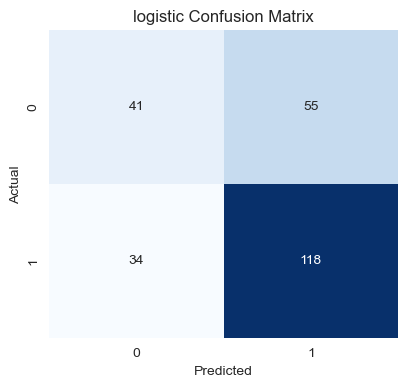


=== random_forest ===
AUC: 0.562
              precision    recall  f1-score   support

           0      0.473     0.271     0.344        96
           1      0.637     0.809     0.713       152

    accuracy                          0.601       248
   macro avg      0.555     0.540     0.529       248
weighted avg      0.574     0.601     0.570       248



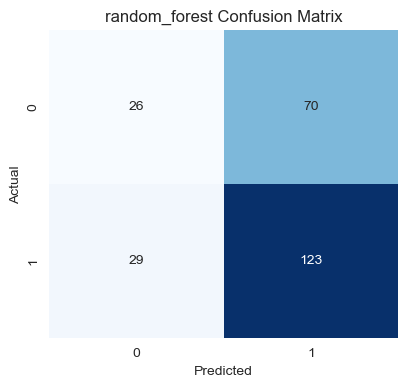


=== xgboost ===
AUC: 0.527
              precision    recall  f1-score   support

           0      0.413     0.323     0.363        96
           1      0.624     0.711     0.665       152

    accuracy                          0.560       248
   macro avg      0.519     0.517     0.514       248
weighted avg      0.543     0.560     0.548       248



c:\Users\Georgia\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:24:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


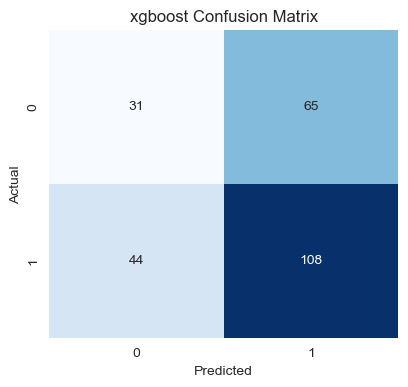


Model comparison


,model,auc,accuracy,precision,recall,f1
0,logistic,0.589844,0.641129,0.682081,0.776316,0.726154
1,random_forest,0.562089,0.600806,0.637306,0.809211,0.713043
2,xgboost,0.527344,0.560484,0.624277,0.710526,0.664615


<Figure size 800x600 with 0 Axes>

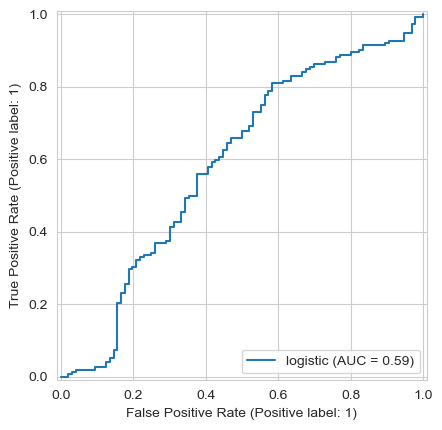

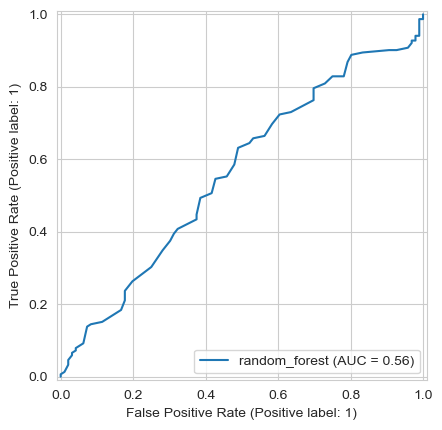

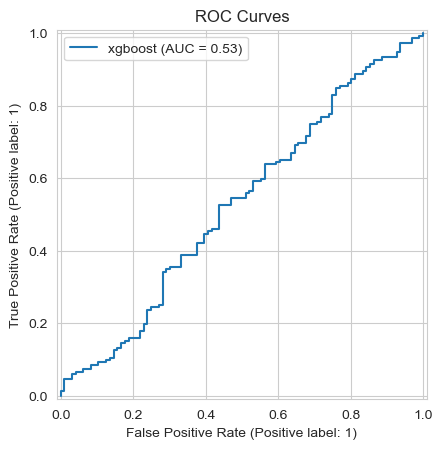

<Figure size 800x600 with 0 Axes>

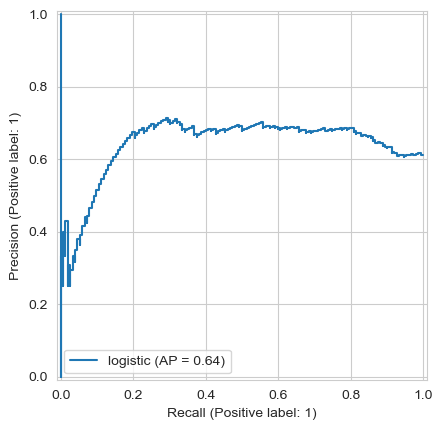

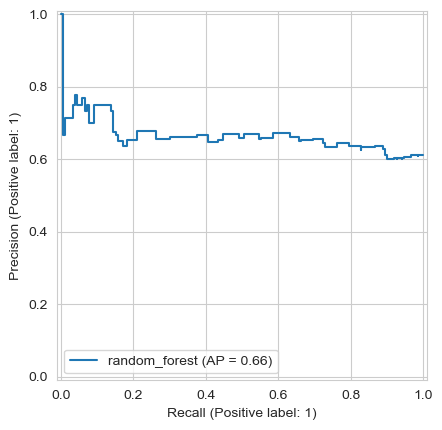

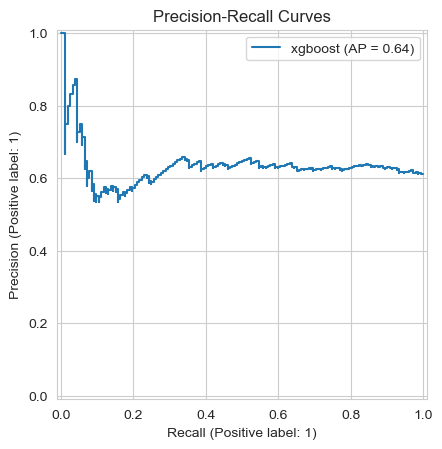

C:\Users\Georgia\AppData\Local\Temp\ipykernel_22416\2906593819.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="feature", data=subset, palette="viridis")


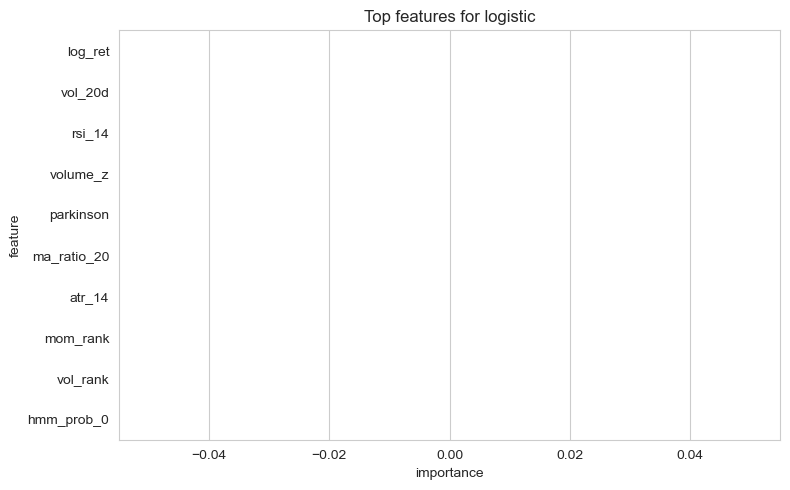

C:\Users\Georgia\AppData\Local\Temp\ipykernel_22416\2906593819.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="feature", data=subset, palette="viridis")


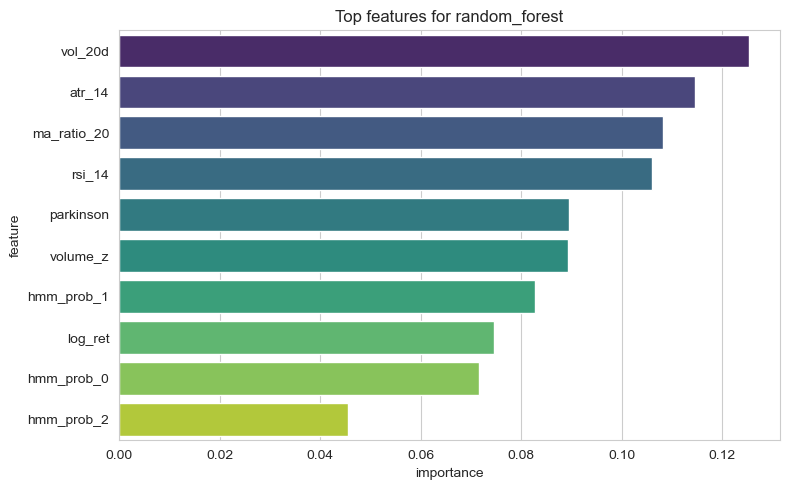

C:\Users\Georgia\AppData\Local\Temp\ipykernel_22416\2906593819.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="feature", data=subset, palette="viridis")


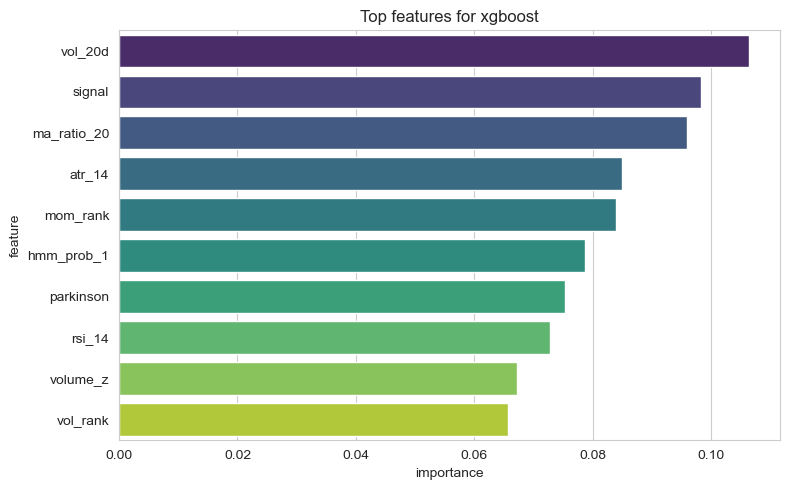

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # use same scaler, don't refit

models = {
    "logistic":      LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "xgboost":       XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    preds = model.predict(X_test_scaled)
    auc = roc_auc_score(y_test, probs)
    report = classification_report(y_test, preds, digits=3, output_dict=True)
    results.append({
        "model": name,
        "auc": auc,
        "accuracy": report["accuracy"],
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
    })

    print(f"\n=== {name} ===")
    print(f"AUC: {auc:.3f}")
    print(classification_report(y_test, preds, digits=3))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Summary table of metrics
metrics_df = pd.DataFrame(results).sort_values("auc", ascending=False).reset_index(drop=True)
print("\nModel comparison")
display(metrics_df)

# ROC curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    RocCurveDisplay.from_predictions(y_test, probs, name=name)
plt.title("ROC Curves")
plt.legend()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=name)
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

# Feature importance / coefficients
feature_importance = []
for name, model in models.items():
    if name == "logistic":
        values = model.coef_[0]
        label = "coefficient"
    else:
        values = model.feature_importances_
        label = "importance"

    tmp = pd.DataFrame({
        "feature": FEATURE_COLS,
        label: values,
        "model": name,
    })
    feature_importance.append(tmp)

importance_df = pd.concat(feature_importance, ignore_index=True)

for model_name in importance_df["model"].unique():
    subset = importance_df[importance_df["model"] == model_name].sort_values(by=label, ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=label, y="feature", data=subset, palette="viridis")
    plt.title(f"Top features for {model_name}")
    plt.tight_layout()
    plt.show()

